In [1]:
import numpy as np
import matplotlib.pyplot as plt


class SigmoidLinearDynamics:
    """
    Model:
        x[t+1] = L x[t] + b + eta[t]
        z[t]   = sigmoid(x[t])

    For deterministic toy examples, use noise_std=0.
    """

    def __init__(self, L, b, x0=None, noise_std=0.0, seed=None):
        self.L = np.asarray(L, dtype=float)
        self.b = np.asarray(b, dtype=float)

        self.K = self.b.size
        assert self.L.shape == (self.K, self.K)

        self.x0 = np.zeros(self.K) if x0 is None else np.asarray(x0, dtype=float)
        assert self.x0.shape == (self.K,)

        self.noise_std = noise_std
        self.rng = np.random.default_rng(seed)

    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    def simulate(self, T):
        x = np.zeros((T, self.K))
        z = np.zeros((T, self.K))

        x[0] = self.x0
        z[0] = self.sigmoid(x[0])

        for t in range(T - 1):
            noise = self.noise_std * self.rng.standard_normal(self.K)
            x[t + 1] = self.L @ x[t] + self.b + noise
            z[t + 1] = self.sigmoid(x[t + 1])

        return x, z

    def onset_times(self, x, threshold=0.0):
        """
        First time each latent x_i crosses threshold.
        """
        onsets = []
        for i in range(x.shape[1]):
            idx = np.where(x[:, i] >= threshold)[0]
            onsets.append(None if len(idx) == 0 else idx[0])
        return onsets

    def plot(self, T=100, title=None):
        x, z = self.simulate(T)
        t = np.arange(T)

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)

        for i in range(self.K):
            axes[0].plot(t, x[:, i], label=f"$x_{i+1}$")
            axes[1].plot(t, z[:, i], label=f"$z_{i+1}$")

        axes[0].axhline(0, linestyle="--", linewidth=1)
        axes[1].axhline(0.5, linestyle="--", linewidth=1)

        axes[0].set_title("latent drive")
        axes[1].set_title("sigmoid activation")

        axes[0].set_xlabel("time")
        axes[1].set_xlabel("time")
        axes[0].set_ylabel("x")
        axes[1].set_ylabel("z")

        for ax in axes:
            ax.legend(frameon=False)

        if title is not None:
            fig.suptitle(title)

        fig.tight_layout()
        return fig, axes, x, z

1D onset: [29]


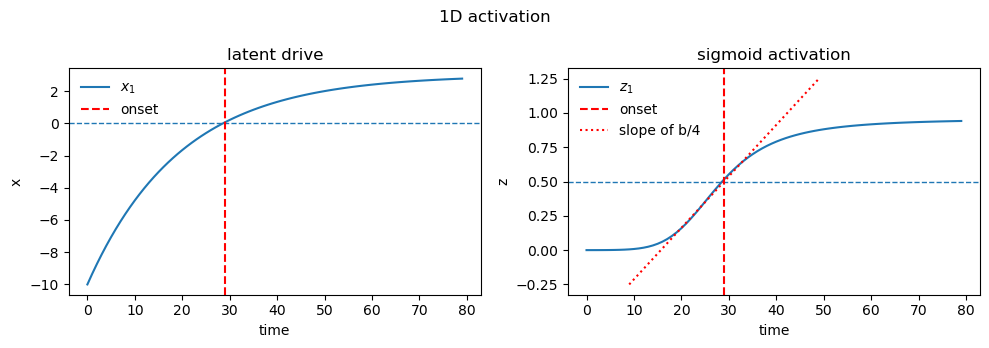

In [23]:
a = 0.95
b = 0.15
x0 = -10.0

model_1d = SigmoidLinearDynamics(
    L=[[a]],
    b=[b],
    x0=[x0],
)

fig, axes, x_1d, z_1d = model_1d.plot(T=80, title="1D activation")

print("1D onset:", model_1d.onset_times(x_1d))
axes[0].axvline(model_1d.onset_times(x_1d)[0], color="red", linestyle="--", label="onset")
axes[0].legend(frameon=False)
axes[1].axvline(model_1d.onset_times(x_1d)[0], color="red", linestyle="--", label="onset")
# Put the slope of b/4 at the onset time to visually confirm it matches the curve
onset_time = model_1d.onset_times(x_1d)[0]
xvals = np.array([onset_time - 20, onset_time + 20])
yvals = (xvals - onset_time) * (b / 4) + 0.5  # slope of b/4 at the onset time
axes[1].plot(
    xvals, yvals,
    color="red",
    linestyle=":",
    label="slope of b/4",
)
axes[1].legend(frameon=False)
fig.tight_layout()

2D onsets: [29, 60]


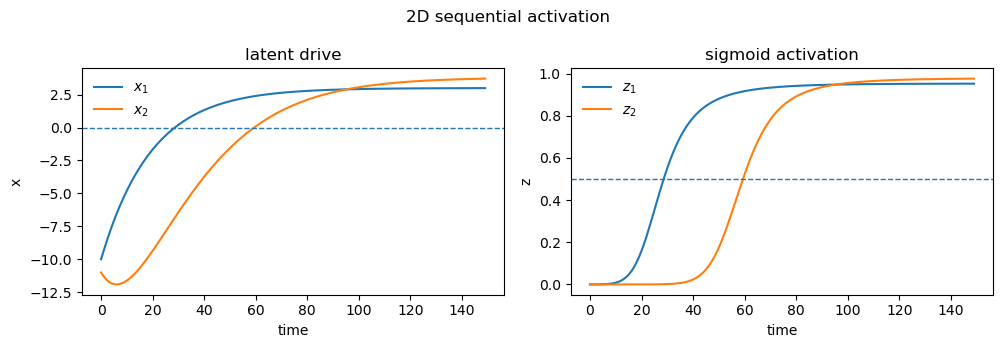

In [24]:
a = 0.95
s = 0.08

L = [
    [a, 0.0],
    [s, a],
]

b = [0.15, -0.05]
x0 = [-10.0, -11.0]

model_2d = SigmoidLinearDynamics(
    L=L,
    b=b,
    x0=x0,
)

fig, axes, x_2d, z_2d = model_2d.plot(T=150, title="2D sequential activation")

print("2D onsets:", model_2d.onset_times(x_2d))

5D onsets: [24, 46, 67, 87, 107]
final z values: [0.98778855 0.99981267 0.999986   1.         0.99999998]


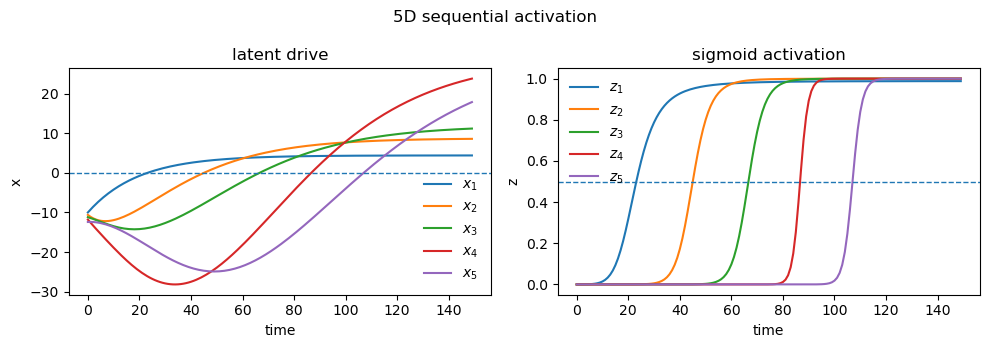

In [26]:
K = 5
T = 150

a = 0.95

subdiag = np.array([0.10, 0.07, 0.12, 0.05])

L = a * np.eye(K)
for i in range(1, K):
    L[i, i - 1] = subdiag[i - 1]

# Slightly stronger drives so all latents approach saturation
b = np.array([0.22, -0.005, -0.015, 0.005, -0.015])

x0 = np.array([-3.0, -3.6, -4.2, -4.8, -5.4]) - 7

model_5d = SigmoidLinearDynamics(
    L=L,
    b=b,
    x0=x0,
    noise_std=0.0,
)

fig, axes, x_5d, z_5d = model_5d.plot(T=T, title="5D sequential activation")

onsets = model_5d.onset_times(x_5d)
print("5D onsets:", onsets)
print("final z values:", z_5d[-1])

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

class SigmoidDynamicFactorModel:
    """
    x[t+1] = L x[t] + b + eta[t]
    z[t]   = sigmoid(x[t])
    y[t]   = C z[t] + d + eps[t]

    p = [a, s1, s2, ..., s_{K-1}]

    L is lower-triangular Toeplitz:

        [[a,   0,   0,   0],
         [s1,  a,   0,   0],
         [s2, s1,   a,   0],
         [s3, s2,  s1,   a]]

    i.e. L[i, j] = p[i-j] for i >= j.
    """

    def __init__(
        self,
        p,
        b,
        C,
        x0=None,
        d=None,
        latent_noise=0.0,
        obs_noise=0.1,
        seed=None,
    ):
        self.rng = np.random.default_rng(seed)

        self.p = np.asarray(p, float)
        self.b = np.asarray(b, float)
        self.C = np.asarray(C, float)

        self.N, self.K = self.C.shape

        assert self.p.shape == (self.K,)
        assert self.b.shape == (self.K,)

        self.L = self.make_L(self.p)

        self.x0 = np.zeros(self.K) if x0 is None else np.asarray(x0, float)
        self.d = np.zeros(self.N) if d is None else np.asarray(d, float)

        assert self.x0.shape == (self.K,)
        assert self.d.shape == (self.N,)

        self.latent_noise = self._as_vec(latent_noise, self.K)
        self.obs_noise = self._as_vec(obs_noise, self.N)

    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def _as_vec(x, n):
        x = np.asarray(x, float)
        if x.ndim == 0:
            return np.full(n, float(x))
        assert x.shape == (n,)
        return x

    @staticmethod
    def make_L(p):
        """
        Build lower-triangular Toeplitz L from p.

        p[0] = diagonal self-persistence
        p[1] = first subdiagonal
        p[2] = second subdiagonal
        ...
        """
        p = np.asarray(p, float)
        K = len(p)

        L = np.zeros((K, K))
        for d in range(K):
            L += np.diag(np.full(K - d, p[d]), k=-d)

        return L

    def simulate_dynamics(self, T):
        x = np.zeros((T, self.K))
        z = np.zeros((T, self.K))

        x[0] = self.x0
        z[0] = self.sigmoid(x[0])

        for t in range(T - 1):
            eta = self.rng.normal(0, self.latent_noise, size=self.K)
            x[t + 1] = self.L @ x[t] + self.b + eta
            z[t + 1] = self.sigmoid(x[t + 1])

        return x, z

    def simulate_onsets(self, T, onsets, slopes, latent_noise=0.0):
        onsets = np.asarray(onsets, float)
        slopes = np.asarray(slopes, float)

        assert onsets.shape == (self.K,)
        assert slopes.shape == (self.K,)

        noise = self._as_vec(latent_noise, self.K)

        t = np.arange(T)[:, None]
        x = slopes[None, :] * (t - onsets[None, :])
        x += self.rng.normal(0, noise, size=x.shape)

        z = self.sigmoid(x)
        return x, z

    def simulate_observations(self, z):
        assert z.shape[1] == self.K

        eps = self.rng.normal(0, self.obs_noise, size=(len(z), self.N))
        y = z @ self.C.T + self.d[None, :] + eps

        return y

    def generate(self, T, mode="dynamics", onsets=None, slopes=None, latent_noise=0.0):
        if mode == "dynamics":
            x, z = self.simulate_dynamics(T)
        elif mode == "onsets":
            x, z = self.simulate_onsets(T, onsets, slopes, latent_noise)
        else:
            raise ValueError("mode must be 'dynamics' or 'onsets'")

        y = self.simulate_observations(z)

        return {
            "x": x,
            "z": z,
            "y": y,
            "L": self.L,
            "p": self.p,
            "b": self.b,
            "C": self.C,
            "d": self.d,
            "x0": self.x0,
            "latent_noise": self.latent_noise,
            "obs_noise": self.obs_noise,
        }

    @staticmethod
    def onset_times(x, threshold=0.0):
        onsets = []
        for i in range(x.shape[1]):
            idx = np.where(x[:, i] >= threshold)[0]
            onsets.append(None if len(idx) == 0 else idx[0])
        return onsets

    @staticmethod
    def plot_latents(x, z):
        T, K = z.shape
        t = np.arange(T)

        fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)

        for i in range(K):
            ax[0].plot(t, x[:, i], label=f"$x_{i+1}$")
            ax[1].plot(t, z[:, i], label=f"$z_{i+1}$")

        ax[0].axhline(0, linestyle="--", linewidth=1)
        ax[1].axhline(0.5, linestyle="--", linewidth=1)

        ax[0].set_title("latent drive")
        ax[1].set_title("activation")
        ax[0].set_xlabel("time")
        ax[1].set_xlabel("time")
        ax[0].set_ylabel("$x$")
        ax[1].set_ylabel("$z$")

        for a in ax:
            a.legend(frameon=False)

        fig.tight_layout()
        return fig, ax

    @staticmethod
    def plot_observations(y):
        plt.figure(figsize=(7, 4))
        plt.imshow(y.T, aspect="auto", origin="lower")
        plt.xlabel("time")
        plt.ylabel("observed channel")
        plt.colorbar(label="$y$")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def initial_sigmoid_latents(T, K, onset_frac=(0.15, 0.85), slope=0.08):
        onsets = np.linspace(onset_frac[0], onset_frac[1], K) * T
        slopes = slope * np.ones(K)
        t = np.arange(T)[:, None]
        x = slopes[None, :] * (t - onsets[None, :])
        z = SigmoidDynamicFactorModel.sigmoid(x)
        return x, z, onsets, slopes

    @staticmethod
    def fit_C_d(y, z):
        T = y.shape[0]
        Z = np.column_stack([z, np.ones(T)])

        B, *_ = np.linalg.lstsq(Z, y, rcond=None)
        C = B[:-1].T
        d = B[-1]
        resid = y - Z @ B
        return C, d, resid

    @staticmethod
    def unpack_theta(theta, K):
        p = theta[:K]
        b = theta[K : 2 * K]
        x0 = theta[2 * K : 3 * K]
        return p, b, x0

    @staticmethod
    def pack_theta(p, b, x0):
        return np.concatenate([p, b, x0])

    @classmethod
    def fit(
        cls,
        y,
        K,
        p0=None,
        b0=None,
        x00=None,
        obs_noise_floor = 1e-6,
        max_nfev=2000,
        seed=None,
        verbose=1
    ):
        y = np.asarray(y, float)
        T, N = y.shape
        rng = np.random.default_rng(seed)

        if p0 is None:
            p0 = np.zeros(K)
            p0[0] = 0.2 + 0.05 * rng.standard_normal()
            p0[1:] = 0.0

        if b0 is None:
            b0 = 0.01 * rng.standard_normal(K)

        if x00 is None:
            x00 = -3.0 - 0.5 * np.arange(K)

        theta0 = cls.pack_theta(p0, b0, x00)

        lower = np.concatenate([
            np.array([0.0]),       # a
            -np.ones(K-1),         # s
            -np.inf * np.ones(K),  # b
            -np.inf * np.ones(K),  # x0
        ])

        upper = np.concatenate([
            np.array([0.999]),     # a
            np.ones(K-1),          # s
            np.inf * np.ones(K),   # b
            np.inf * np.ones(K),   # x0
        ])

        def residual_fun(theta):
            p, b, x0 = cls.unpack_theta(theta, K)
            C_dummy = np.zeros((N, K))
            model = cls(
                p=p,
                b=b,
                C=C_dummy,
                x0=x0,
                obs_noise=1.0,
                latent_noise=0.,
                seed = seed,
            )

            x, z = model.simulate_dynamics(T)
            C, d, resid = cls.fit_C_d(y, z)

            return resid.ravel()

        result = least_squares(
            residual_fun,
            theta0,
            bounds=(lower, upper),
            max_nfev=max_nfev,
            verbose=verbose,
        )

        p_hat, b_hat, x0_hat = cls.unpack_theta(result.x, K)

        C_dummy = np.zeros((N, K))
        tmp = cls(
            p=p_hat,
            b=b_hat,
            C=C_dummy,
            x0=x0_hat,
            obs_noise=1.0,
            latent_noise=0.,
            seed=seed,
        )

        x_hat, z_hat = tmp.simulate_dynamics(T)
        C_hat, d_hat, resid = cls.fit_C_d(y, z_hat)

        obs_noise_hat = np.sqrt(np.mean(resid**2, axis=0) + obs_noise_floor)

        fitted = cls(
            p=p_hat,
            b=b_hat,
            C=C_hat,
            x0=x0_hat,
            d=d_hat,
            obs_noise=obs_noise_hat,
            latent_noise=0.0,
            seed=seed,
        )

        return {
            "model": fitted,
            "x": x_hat,
            "z": z_hat,
            "yhat": z_hat @ C_hat.T + d_hat[None, :],
            "residuals": resid,
            "obs_noise": obs_noise_hat,
            "result": result,
        }

onsets: [np.int64(26), np.int64(55), np.int64(86), np.int64(114), np.int64(145)]


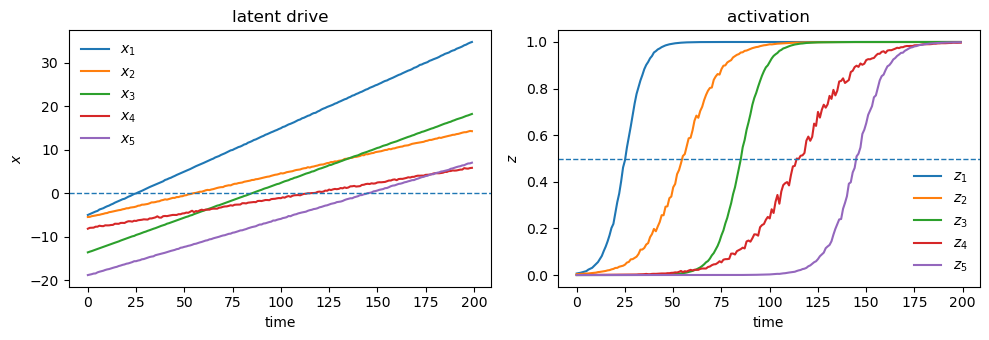

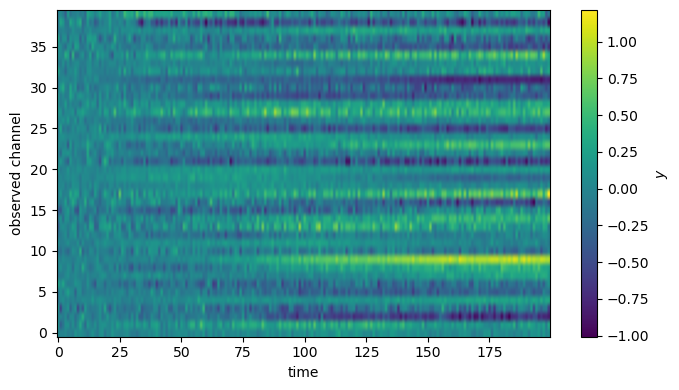

In [12]:
K = 5
N = 40
T = 200

rng = np.random.default_rng(0)

C = rng.normal(size=(N, K))
C /= np.linalg.norm(C, axis=0, keepdims=True)

p = np.array([0.95, 0.08, 0.08, 0.08, 0.08])
b = np.zeros(K)

obs_noise = rng.uniform(0.05, 0.20, size=N)
latent_noise = np.array([0.03, 0.05, 0.02, 0.08, 0.04])

model = SigmoidDynamicFactorModel(
    p=p,
    b=b,
    C=C,
    obs_noise=obs_noise,
    latent_noise=latent_noise,
    seed=1,
)

onsets = np.array([25, 55, 85, 115, 145])
slopes = np.array([0.20, 0.10, 0.16, 0.07, 0.13])

data = model.generate(
    T=T,
    mode="onsets",
    onsets=onsets,
    slopes=slopes,
    latent_noise=latent_noise,
)

x, z, y = data["x"], data["z"], data["y"]

print("onsets:", model.onset_times(x))

model.plot_latents(x, z)
model.plot_observations(y)

In [13]:
fit = SigmoidDynamicFactorModel.fit(
    y,
    K=5,
    seed=2,
    max_nfev=5000,
)

`ftol` termination condition is satisfied.
Function evaluations 154, initial cost 1.5468e+02, final cost 1.4975e+02, first-order optimality 1.46e+01.


In [15]:
model_hat = fit["model"]
x_hat = fit["x"]
z_hat = fit["z"]
yhat = fit["yhat"]

print("p_hat:", model_hat.p)
print("b_hat:", model_hat.b)
print("x0_hat:", model_hat.x0)

p_hat: [ 0.31397219  0.0016755   0.00407556 -0.00869495  0.00075418]
b_hat: [-0.01026054  0.00826575 -0.02761092  0.02162824 -0.00036566]
x0_hat: [-3.00112291 -3.50238992 -4.00793462 -4.50835807 -4.97837302]


In [16]:
fit.keys()

dict_keys(['model', 'x', 'z', 'yhat', 'residuals', 'obs_noise', 'result'])

(<Figure size 1000x350 with 2 Axes>,
 array([<Axes: title={'center': 'latent drive'}, xlabel='time', ylabel='$x$'>,
        <Axes: title={'center': 'activation'}, xlabel='time', ylabel='$z$'>],
       dtype=object))

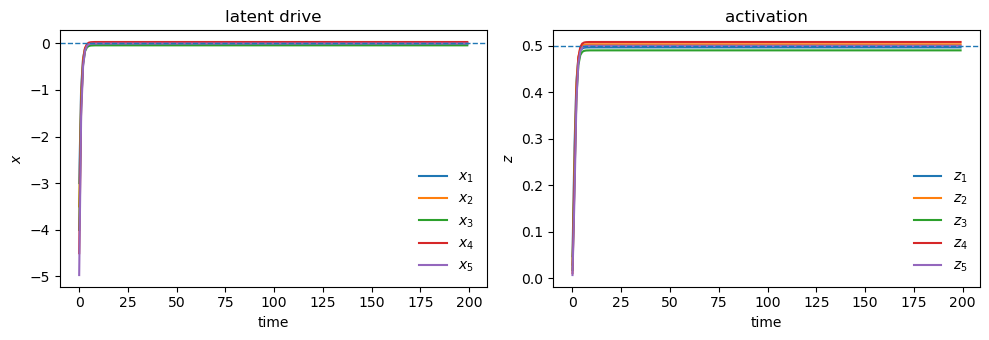

In [17]:
fit["model"].plot_latents(x_hat, z_hat)

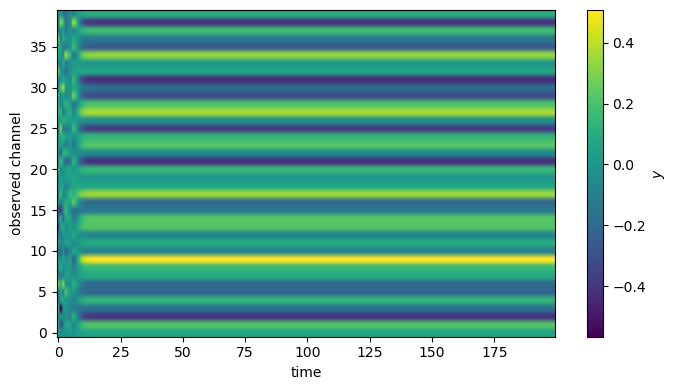

In [18]:
fit["model"].plot_observations(yhat)